## Objetivo da análise: entender os fatores associados ao cancelamento dos clientes de uma plataforma de streaming.

In [1]:
import pandas as pd

df = pd.read_csv('../data/Streaming.csv')

df.head()

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0


## Tamanho do dataset e informacoes dos dados

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


## Quantidade de valores nulos por coluna

In [3]:
df.isna().sum()

# df.isna().mean() * 100

Customer_ID                 0
Age                       500
Gender                      0
Subscription_Length         0
Region                      0
Payment_Method              0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

## Quantidade de dados duplicados 

In [4]:
df.duplicated().sum()

0

In [5]:
df["Customer_ID"].duplicated().sum()

0

## Categorias e quantidade das colunas do tipo "object"

In [6]:

valores_gen = df["Gender"].value_counts()

valores_reg = df["Region"].value_counts()

valores_metpag = df["Payment_Method"].value_counts()

print(valores_gen, valores_reg, valores_metpag, sep="\n\n")

Gender
Female    2514
Male      2486
Name: count, dtype: int64

Region
West     1316
North    1243
South    1239
East     1202
Name: count, dtype: int64

Payment_Method
Debit Card     1697
PayPal         1673
Credit Card    1630
Name: count, dtype: int64


## Quantidade e proporcao de cancelamento

In [7]:
df["Churned"].value_counts()

Churned
0    2760
1    2240
Name: count, dtype: int64

In [8]:
df["Churned"].value_counts(normalize=True) * 100

Churned
0    55.2
1    44.8
Name: proportion, dtype: float64

## Variaveis numericas

In [9]:
df.describe()

,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,4500.000000,5000.000000,5000.000000,4500.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,29.704400,2.037000,5.54600,12.458404,181.441400,46.619784,0.448000
std,14.969559,17.050336,1.422405,2.86929,4.325381,104.500951,9.522140,0.497338
min,18.000000,1.000000,0.000000,1.00000,5.000000,1.000000,-5.060000,0.000000
25%,31.000000,15.000000,1.000000,3.00000,8.700000,90.000000,39.897500,0.000000
50%,43.000000,29.000000,2.000000,6.00000,12.500000,182.000000,46.625000,0.000000
75%,56.000000,44.000000,3.000000,8.00000,16.190000,271.000000,53.210000,1.000000
max,69.000000,59.000000,9.000000,10.00000,20.000000,364.000000,137.310000,1.000000


## Analise de anomalia (valor negativo na coluna "Monthly_Spend")

In [10]:
(df["Monthly_Spend"] < 0).sum()

2

In [11]:
df[df["Monthly_Spend"] < 0]

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
1353,CUST001354,18.0,Male,33,South,PayPal,2,4.0,7.18,205,-5.06,0
3929,CUST003930,66.0,Female,10,East,Debit Card,1,2.0,14.65,140,-3.52,1


## Investigacao de valores ausentes

In [12]:
(df.groupby(df["Age"].isna())["Churned"].mean() * 100).round(2)

Age
False    44.87
True     44.20
Name: Churned, dtype: float64

In [13]:
(df.groupby(df["Satisfaction_Score"].isna())["Churned"].mean() * 100).round(2)

Satisfaction_Score
False    44.96
True     43.40
Name: Churned, dtype: float64

## Investigacao tabela "Age"

In [14]:
df["Age"].describe().round(2)

count    4500.00
mean       43.58
std        14.97
min        18.00
25%        31.00
50%        43.00
75%        56.00
max        69.00
Name: Age, dtype: float64

In [15]:
df["Age"].value_counts().sort_index()

Age
18.0     88
19.0     83
20.0     88
21.0     91
22.0     84
23.0     87
24.0     67
25.0     97
26.0     85
27.0     82
28.0     88
29.0     88
30.0     83
31.0     87
32.0     83
33.0     67
34.0     95
35.0     81
36.0     84
37.0     89
38.0     98
39.0     94
40.0     90
41.0     87
42.0     88
43.0     97
44.0     67
45.0     99
46.0     95
47.0     86
48.0     63
49.0     97
50.0     94
51.0     93
52.0    103
53.0     85
54.0     94
55.0     78
56.0     87
57.0     82
58.0     86
59.0     73
60.0     62
61.0     88
62.0    103
63.0     70
64.0    109
65.0     72
66.0    110
67.0     78
68.0     98
69.0     77
Name: count, dtype: int64

## Investigacao tabela "Satisfaction_Score"

In [16]:
df["Satisfaction_Score"].describe().round(2)

count    4500.00
mean        5.55
std         2.87
min         1.00
25%         3.00
50%         6.00
75%         8.00
max        10.00
Name: Satisfaction_Score, dtype: float64

In [17]:
df["Satisfaction_Score"].value_counts().sort_index()

Satisfaction_Score
1.0     450
2.0     439
3.0     407
4.0     469
5.0     436
6.0     477
7.0     463
8.0     449
9.0     443
10.0    467
Name: count, dtype: int64

## Relacao entre dados faltantes

In [18]:
pd.crosstab(
    df["Age"].isna(),
    df["Satisfaction_Score"].isna()
)

Satisfaction_Score,False,True
Age,,
False,4053,447
True,447,53


In [19]:
df["dados_faltantes"] = (
    df["Age"].isna().astype(str) + "_" +
    df["Satisfaction_Score"].isna().astype(str)
)

In [20]:
df.groupby("dados_faltantes")["Churned"].agg(
    ["count", "mean"]
)

,count,mean
dados_faltantes,,
False_False,4053,0.448557
False_True,447,0.449664
True_False,447,0.458613
True_True,53,0.301887


## Tratamento dos dados ausentes (imputados com base na mediana)

In [21]:
df_tratado = df.copy()

In [22]:
df_tratado["Age"] = df_tratado["Age"].fillna(
    df_tratado["Age"].median()
)

df_tratado["Satisfaction_Score"] = df_tratado["Satisfaction_Score"].fillna(
    df_tratado["Satisfaction_Score"].median()
)

In [23]:
df_tratado[["Age", "Satisfaction_Score"]].isna().sum()

Age                   0
Satisfaction_Score    0
dtype: int64

## Tratamento dados negativos (imputados com base na mediana novamente)

In [24]:
df_tratado[df_tratado["Monthly_Spend"] < 0][
    ["Customer_ID", "Monthly_Spend", "Churned"]
]

,Customer_ID,Monthly_Spend,Churned
1353,CUST001354,-5.06,0
3929,CUST003930,-3.52,1


In [25]:
df_tratado["Monthly_Spend"].sort_values().head(10)

1353    -5.06
3929    -3.52
2607    21.77
175     23.15
3630    23.18
4023    23.18
3166    23.53
4973    23.76
2685    23.95
3190    24.05
Name: Monthly_Spend, dtype: float64

In [26]:
df_tratado.loc[
    df_tratado["Monthly_Spend"] >= 0,
    "Monthly_Spend"
].median()

46.63

In [27]:
df_tratado.loc[
    df_tratado["Monthly_Spend"] < 0,
    "Monthly_Spend"
] = pd.NA

In [28]:
mediana_spend = df_tratado["Monthly_Spend"].median()

df_tratado["Monthly_Spend"] = df_tratado["Monthly_Spend"].fillna(
    mediana_spend
)

In [29]:
df_tratado["Monthly_Spend"].describe().round(2)

count    5000.00
mean       46.64
std         9.47
min        21.77
25%        39.90
50%        46.63
75%        53.21
max       137.31
Name: Monthly_Spend, dtype: float64

## Verificacao de qualidade dos dados

In [30]:
print("Valores negativos:", (df_tratado["Monthly_Spend"] < 0).sum())
print("Valores ausentes:", df_tratado["Monthly_Spend"].isna().sum())

Valores negativos: 0
Valores ausentes: 0


In [31]:
df_tratado = df_tratado.drop(columns=["dados_faltantes"])

df_tratado.shape

(5000, 12)

In [32]:
df_tratado.isna().sum()

Customer_ID               0
Age                       0
Gender                    0
Subscription_Length       0
Region                    0
Payment_Method            0
Support_Tickets_Raised    0
Satisfaction_Score        0
Discount_Offered          0
Last_Activity             0
Monthly_Spend             0
Churned                   0
dtype: int64

In [33]:
(df_tratado["Monthly_Spend"] < 0).sum()

0

In [34]:
print("Linhas duplicadas:", df_tratado.duplicated().sum())
print("Customer_ID duplicados:", df_tratado["Customer_ID"].duplicated().sum())

Linhas duplicadas: 0
Customer_ID duplicados: 0


In [35]:
df_tratado.shape

(5000, 12)

## Correlacao valores numericos

In [36]:
correlacao = df_tratado[
    [
        "Age",
        "Subscription_Length",
        "Support_Tickets_Raised",
        "Satisfaction_Score",
        "Discount_Offered",
        "Last_Activity",
        "Monthly_Spend",
        "Churned"
    ]
].corr()

correlacao

,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
Age,1.000000,0.001671,-0.001148,-0.003222,0.033971,0.021490,0.006567,0.008446
Subscription_Length,0.001671,1.000000,0.010192,0.014288,-0.005831,-0.005180,0.548820,0.002056
Support_Tickets_Raised,-0.001148,0.010192,1.000000,0.015098,0.010808,0.010484,-0.162687,0.154712
Satisfaction_Score,-0.003222,0.014288,0.015098,1.000000,-0.001312,0.016158,0.723944,-0.537304
Discount_Offered,0.033971,-0.005831,0.010808,-0.001312,1.000000,0.013147,0.216444,0.006932
Last_Activity,0.021490,-0.005180,0.010484,0.016158,0.013147,1.000000,0.004759,0.338888
Monthly_Spend,0.006567,0.548820,-0.162687,0.723944,0.216444,0.004759,1.000000,-0.449852
Churned,0.008446,0.002056,0.154712,-0.537304,0.006932,0.338888,-0.449852,1.000000


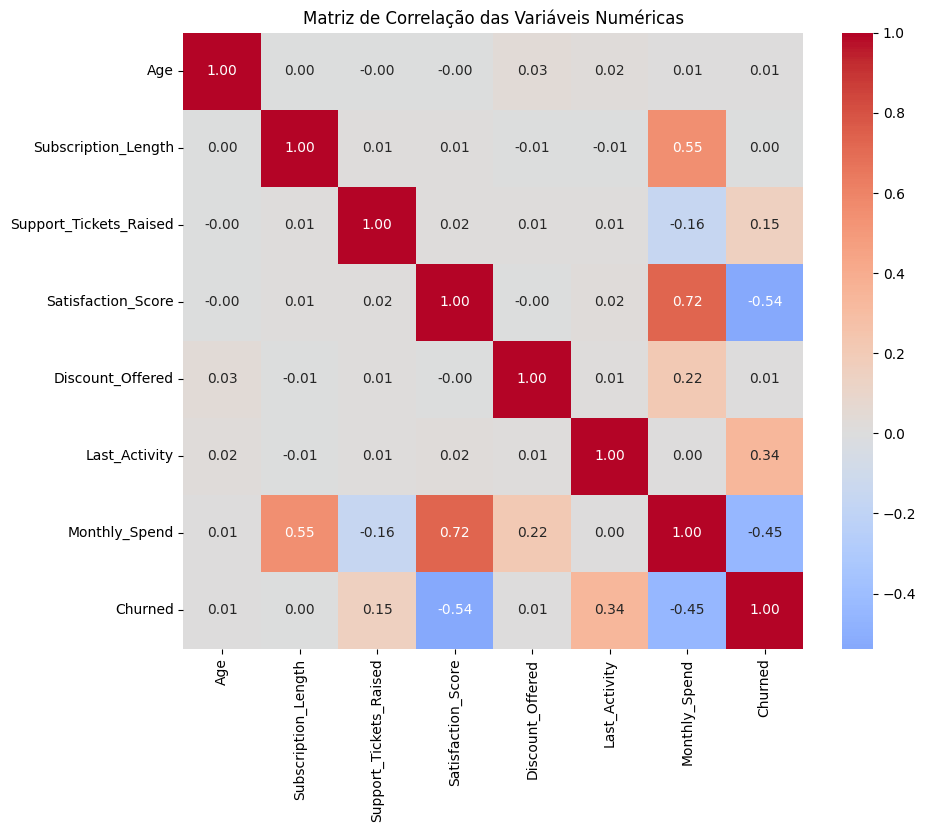

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

In [38]:
churn_geral = df_tratado["Churned"].mean()

print(f"Taxa geral de churn: {churn_geral:.2%}")

Taxa geral de churn: 44.80%


## Hipótese 1: Subscription_Length
#### "Clientes com maior tempo de assinatura apresentam maior churn em comparação com clientes a menor tempo de assinatura."

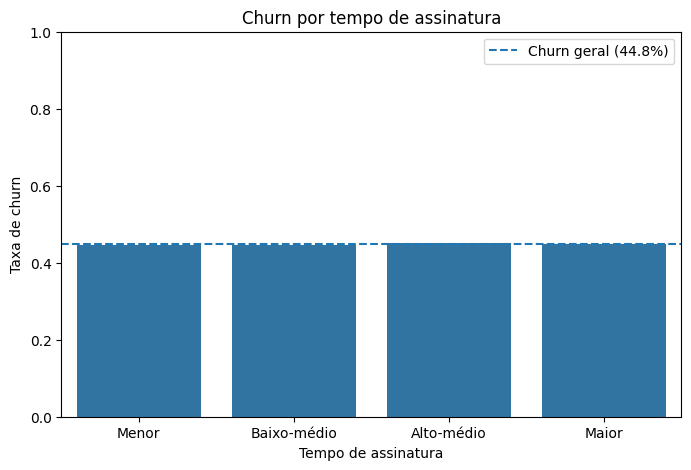

,Faixa_Subscription,Churned
0,Menor,0.446775
1,Baixo-médio,0.446791
2,Alto-médio,0.450241
3,Maior,0.448220


In [39]:
df_tratado["Faixa_Subscription"] = pd.qcut(
    df_tratado["Subscription_Length"],
    q=4,
    labels=["Menor", "Baixo-médio", "Alto-médio", "Maior"],
    duplicates="drop"
)

churn_subscription = (
    df_tratado.groupby("Faixa_Subscription", observed=True)["Churned"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_subscription,
    x="Faixa_Subscription",
    y="Churned"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por tempo de assinatura")
plt.xlabel("Tempo de assinatura")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_subscription

## Hipótese 2 — Gasto mensal
#### Quanto maior o Monthly_Spend, maior a taxa de churn.

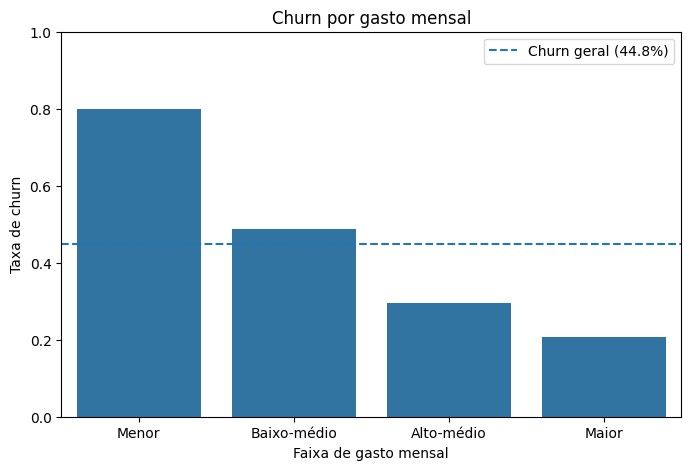

,Faixa_Monthly_Spend,Churned
0,Menor,0.800160
1,Baixo-médio,0.488818
2,Alto-médio,0.295436
3,Maior,0.206731


In [40]:
df_tratado["Faixa_Monthly_Spend"] = pd.qcut(
    df_tratado["Monthly_Spend"],
    q=4,
    labels=["Menor", "Baixo-médio", "Alto-médio", "Maior"],
    duplicates="drop"
)

churn_spend = (
    df_tratado.groupby("Faixa_Monthly_Spend", observed=True)["Churned"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_spend,
    x="Faixa_Monthly_Spend",
    y="Churned"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por gasto mensal")
plt.xlabel("Faixa de gasto mensal")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_spend

## Hipótese 3 — Desconto
#### Quanto menor o Discount_Offered, maior a taxa de churn.

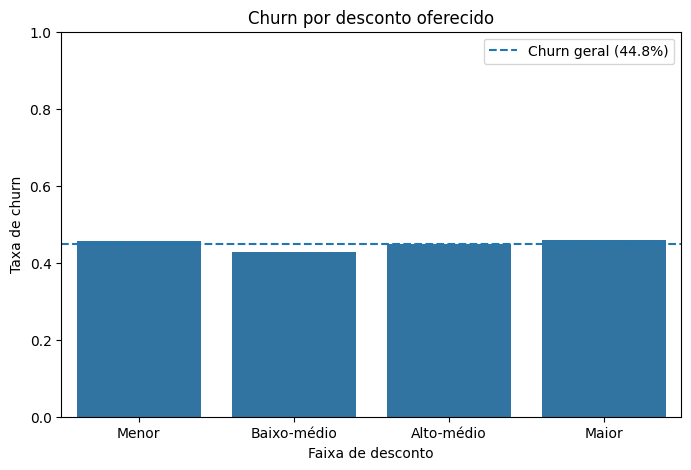

,Faixa_Discount,Churned
0,Menor,0.456504
1,Baixo-médio,0.428000
2,Alto-médio,0.447725
3,Maior,0.459807


In [41]:
df_tratado["Faixa_Discount"] = pd.qcut(
    df_tratado["Discount_Offered"],
    q=4,
    labels=["Menor", "Baixo-médio", "Alto-médio", "Maior"],
    duplicates="drop"
)

churn_discount = (
    df_tratado.groupby("Faixa_Discount", observed=True)["Churned"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_discount,
    x="Faixa_Discount",
    y="Churned"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por desconto oferecido")
plt.xlabel("Faixa de desconto")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_discount

## Hipótese 4 — Método de pagamento
#### Clientes que utilizam cartão de débito apresentam maior churn.

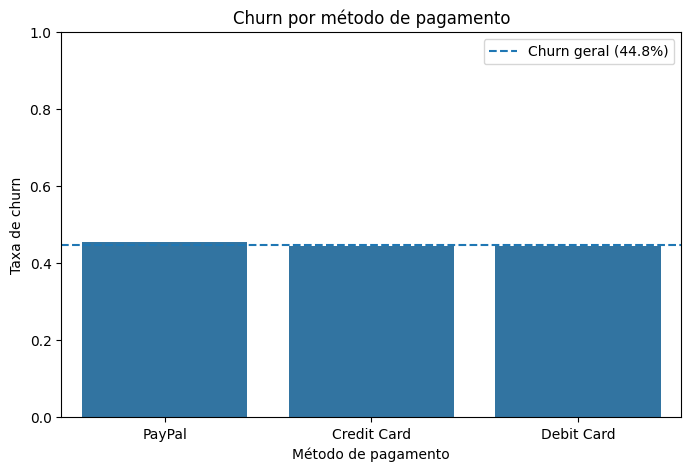

,Payment_Method,Churned
0,PayPal,0.454871
1,Credit Card,0.445399
2,Debit Card,0.443724


In [42]:
churn_payment = (
    df_tratado.groupby("Payment_Method")["Churned"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_payment,
    x="Payment_Method",
    y="Churned"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_payment

## Hipótese 5 — Tickets de suporte
#### Quanto maior o número de Support_Tickets_Raised, maior o churn.

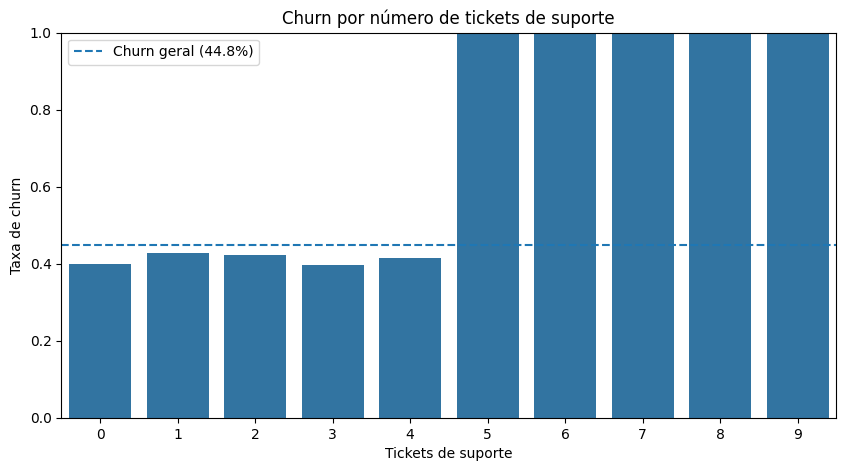

,Support_Tickets_Raised,count,mean
0,0,628,0.398089
1,1,1340,0.429104
2,2,1403,0.421953
3,3,890,0.397753
4,4,461,0.414317
5,5,180,1.000000
6,6,67,1.000000
7,7,26,1.000000
8,8,4,1.000000
9,9,1,1.000000


In [43]:
churn_tickets = (
    df_tratado.groupby("Support_Tickets_Raised")["Churned"]
    .agg(["count", "mean"])
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=churn_tickets,
    x="Support_Tickets_Raised",
    y="mean"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por número de tickets de suporte")
plt.xlabel("Tickets de suporte")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_tickets

## Hipótese 6 — Idade
#### Clientes mais velhos apresentam maior churn.

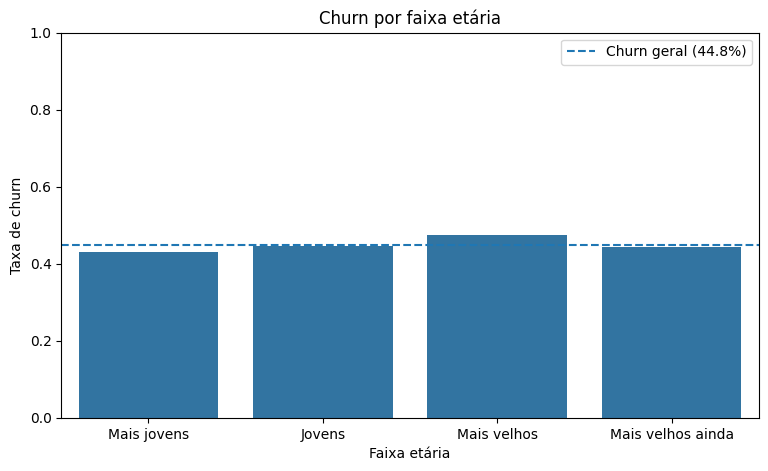

,Faixa_Age,Churned
0,Mais jovens,0.431694
1,Jovens,0.446259
2,Mais velhos,0.474383
3,Mais velhos ainda,0.444351


In [44]:
df_tratado["Faixa_Age"] = pd.qcut(
    df_tratado["Age"],
    q=4,
    labels=["Mais jovens", "Jovens", "Mais velhos", "Mais velhos ainda"],
    duplicates="drop"
)

churn_age = (
    df_tratado.groupby("Faixa_Age", observed=True)["Churned"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=churn_age,
    x="Faixa_Age",
    y="Churned"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_age

## Hipótese 7 — Inatividade
#### Quanto maior o Last_Activity, maior a taxa de churn.

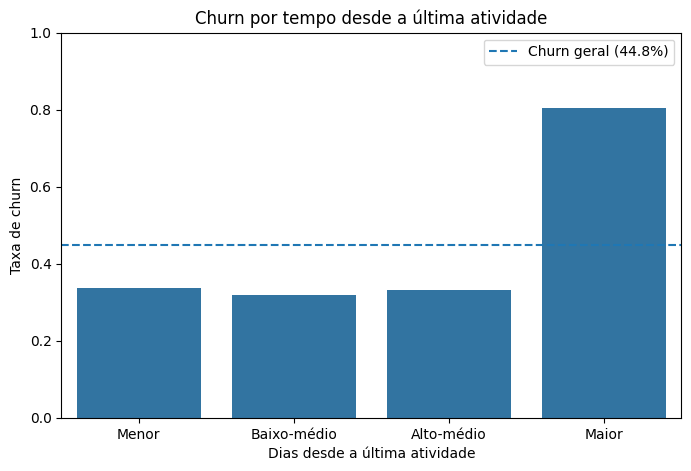

,Faixa_Last_Activity,Churned
0,Menor,0.337838
1,Baixo-médio,0.318620
2,Alto-médio,0.331735
3,Maior,0.805622


In [45]:
df_tratado["Faixa_Last_Activity"] = pd.qcut(
    df_tratado["Last_Activity"],
    q=4,
    labels=["Menor", "Baixo-médio", "Alto-médio", "Maior"],
    duplicates="drop"
)

churn_activity = (
    df_tratado.groupby("Faixa_Last_Activity", observed=True)["Churned"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=churn_activity,
    x="Faixa_Last_Activity",
    y="Churned"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por tempo desde a última atividade")
plt.xlabel("Dias desde a última atividade")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_activity

## Hipótese 8 — Satisfação
#### Clientes com menor Satisfaction_Score apresentam maior taxa de churn.

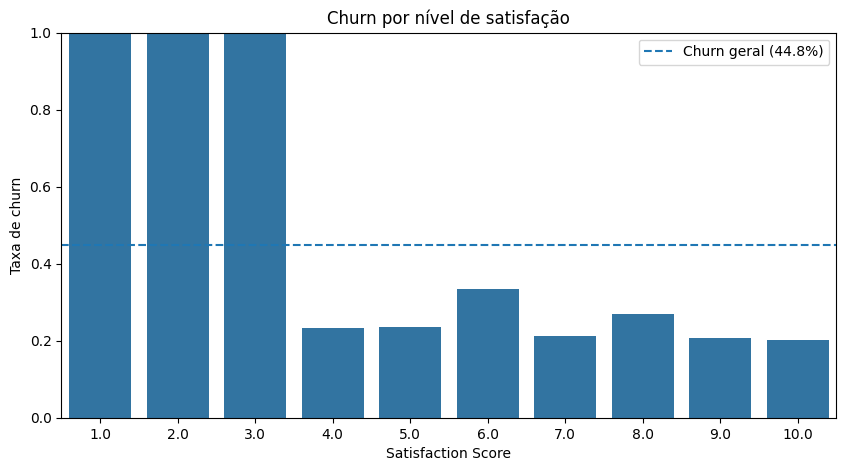

,Satisfaction_Score,count,mean
0,1.0,450,1.000000
1,2.0,439,1.000000
2,3.0,407,1.000000
3,4.0,469,0.232409
4,5.0,436,0.236239
5,6.0,977,0.334698
6,7.0,463,0.211663
7,8.0,449,0.269488
8,9.0,443,0.207675
9,10.0,467,0.201285


In [46]:
churn_satisfaction = (
    df_tratado.groupby("Satisfaction_Score")["Churned"]
    .agg(["count", "mean"])
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=churn_satisfaction,
    x="Satisfaction_Score",
    y="mean"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por nível de satisfação")
plt.xlabel("Satisfaction Score")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

churn_satisfaction

## Investigação das hipóteses

#### Support Tickets

In [47]:
df_tratado["Faixa_Tickets"] = df_tratado["Support_Tickets_Raised"].apply(
    lambda x: "0 a 4 tickets" if x <= 4 else "5 ou mais tickets"
)

resultado_tickets = (
    df_tratado.groupby("Faixa_Tickets")["Churned"]
    .agg(["count", "mean"])
)

resultado_tickets

,count,mean
Faixa_Tickets,,
0 a 4 tickets,4722,0.415502
5 ou mais tickets,278,1.000000


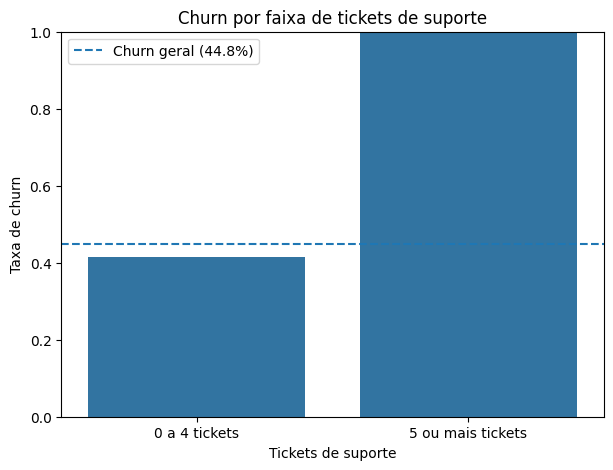

In [48]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=resultado_tickets.reset_index(),
    x="Faixa_Tickets",
    y="mean"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por faixa de tickets de suporte")
plt.xlabel("Tickets de suporte")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [49]:
print(df_tratado[df_tratado["Support_Tickets_Raised"] >= 5][
    ["Customer_ID", "Support_Tickets_Raised", "Satisfaction_Score", 
     "Last_Activity", "Monthly_Spend", "Churned"]
].describe())

print("\nQuantidade de clientes com 5+ tickets:", 
      (df_tratado["Support_Tickets_Raised"] >= 5).sum())
print("Proporção da base:", 
      (df_tratado["Support_Tickets_Raised"] >= 5).mean() * 100, "%")

       Support_Tickets_Raised  Satisfaction_Score  Last_Activity  \
count              278.000000          278.000000     278.000000   
mean                 5.485612            5.784173     183.859712   
std                  0.753913            2.548483     101.028993   
min                  5.000000            1.000000       2.000000   
25%                  5.000000            4.000000      92.000000   
50%                  5.000000            6.000000     190.500000   
75%                  6.000000            8.000000     263.000000   
max                  9.000000           10.000000     362.000000   

       Monthly_Spend  Churned  
count      278.00000    278.0  
mean        43.84446      1.0  
std          8.41632      0.0  
min         21.77000      1.0  
25%         38.79750      1.0  
50%         43.64000      1.0  
75%         49.74000      1.0  
max         63.22000      1.0  

Quantidade de clientes com 5+ tickets: 278
Proporção da base: 5.56 %


#### Monthly Spend

In [50]:
df_tratado["Faixa_Gasto"] = pd.cut(
    df_tratado["Monthly_Spend"],
    bins=[-float("inf"), 30, 40, 50, 60, float("inf")],
    labels=["Até 30", "30–40", "40–50", "50–60", "Acima de 60"]
)

resultado_gasto = (
    df_tratado.groupby("Faixa_Gasto", observed=True)["Churned"]
    .agg(["count", "mean"])
)

resultado_gasto

,count,mean
Faixa_Gasto,,
Até 30,172,1.000000
30–40,1096,0.763686
40–50,1865,0.441287
50–60,1462,0.225718
Acima de 60,405,0.192593


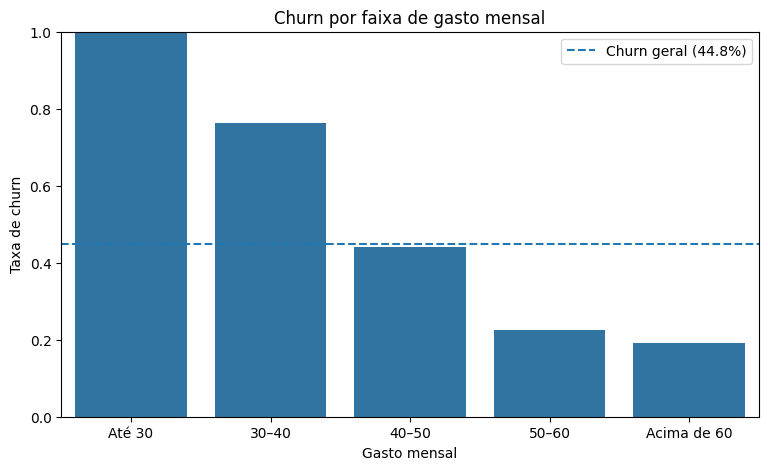

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=resultado_gasto.reset_index(),
    x="Faixa_Gasto",
    y="mean"
)

plt.axhline(
    churn_geral,
    linestyle="--",
    label=f"Churn geral ({churn_geral:.1%})"
)

plt.title("Churn por faixa de gasto mensal")
plt.xlabel("Gasto mensal")
plt.ylabel("Taxa de churn")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [52]:
resultado_tickets_gasto = pd.crosstab(
    df_tratado["Faixa_Gasto"],
    df_tratado["Faixa_Tickets"],
    normalize="index"
) * 100

resultado_tickets_gasto

Faixa_Tickets,0 a 4 tickets,5 ou mais tickets
Faixa_Gasto,,
Até 30,90.697674,9.302326
30–40,93.521898,6.478102
40–50,93.243968,6.756032
50–60,96.032832,3.967168
Acima de 60,98.271605,1.728395


## Arquivo tratado pro dashboard 

In [53]:
df_tratado.to_csv(
    "../data/churn_tratado.csv",
    index=False
)